Cell 1: Install Required Libraries

In [1]:
# Install necessary packages (run once)
!pip install xgboost shap lime networkx python-louvain -q
print("✅ Packages installed successfully!")

✅ Packages installed successfully!


'pip' is not recognized as an internal or external command,
operable program or batch file.


Cell 2: Imports and Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from community import community_louvain
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve,
    hamming_loss
)
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

# XGBoost
import xgboost as xgb

# XAI Libraries
import shap
from lime.lime_tabular import LimeTabularExplainer

# Model persistence
import pickle
import json
from datetime import datetime

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All imports successful!")

✅ All imports successful!


Cell 3: Configuration and Constants

In [4]:
# ============================================================
# CONFIGURATION
# ============================================================

# Clinical thresholds (can be adjusted)
THRESHOLDS = {
    'cholesterol_high': 200,      # mg/dL
    'glucose_high': 100,           # mg/dL
    'bp_systolic_high': 140,       # mmHg
    'bp_diastolic_high': 90,       # mmHg
    'bmi_obese': 30,               # kg/m²
    'exercise_min': 2,              # hours/week
    'age_risk': 50                  # years
}

# Feature columns (will be updated after encoding)
BASE_FEATURES = [
    'Age', 'Gender', 'Height cm', 'Weight kg', 'Blood Pressure mmHg',
    'Cholesterol mg/dL', 'Glucose mg/dL', 'Smoker', 'Exercise hours/week'
]

# Recommendation categories
RECOMMENDATION_CATEGORIES = [
    'Low_Risk', 'High_Risk', 'Smoking_Cessation',
    'Diet_Cholesterol', 'Exercise', 'BP_Control', 'Maintenance'
]

# Templates for natural language generation (filled dynamically)
REC_TEMPLATES = {
    'Low_Risk': {
        'action': "Maintain a healthy lifestyle and attend regular checkups.",
        'rationale': "Your risk profile is favorable."
    },
    'High_Risk': {
        'action': "Seek medical advice {urgency} for a comprehensive cardiovascular evaluation.",
        'rationale': "Your overall risk profile indicates potential cardiovascular concerns."
    },
    'Smoking_Cessation': {
        'action': "Stop smoking immediately. Consider nicotine replacement therapy or counseling.",
        'rationale': "Smoking significantly increases cardiovascular risk."
    },
    'Diet_Cholesterol': {
        'action': "Adopt a heart‑healthy diet low in saturated fats and cholesterol.",
        'rationale': "Your cholesterol level ({cholesterol} mg/dL) is elevated."
    },
    'Exercise': {
        'action': "Increase physical activity to at least 150 minutes of moderate exercise per week.",
        'rationale': "Your current exercise ({exercise} hours/week) is below recommended levels."
    },
    'BP_Control': {
        'action': "Monitor your blood pressure regularly and consider lifestyle modifications or medication.",
        'rationale': "Your blood pressure ({bp_sys}/{bp_dia}) is elevated."
    },
    'Maintenance': {
        'action': "Continue with regular health screenings and maintain healthy habits.",
        'rationale': "No major risk factors detected; focus on prevention."
    }
}

print("✅ Configuration loaded.")

✅ Configuration loaded.


Cell 4: Load and Explore Data

In [6]:
# Load dataset
df = pd.read_csv(r'C:\Users\User\Desktop\DSGP Viva\model\CM2603-DSGP-Group-3\Dataset\converted_patient_format.csv')

print(f"📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n📋 First 5 rows:")
df.head()

📊 Dataset Shape: 724 rows × 13 columns

📋 First 5 rows:


,ID,Name,Age,Gender,Height cm,Weight kg,Blood Pressure mmHg,Cholesterol mg/dL,Glucose mg/dL,Smoker,Exercise hours/week,Heart Attack,recommendation
0,1,Patient 1,35,Female,160,65,110/70,180,80,No,2,0,Low risk. Maintain a healthy lifestyle and att...
1,2,Patient 2,40,Female,165,70,115/75,190,85,No,3,0,Low risk. Maintain a healthy lifestyle and att...
2,3,Patient 3,30,Female,155,60,105/65,170,75,No,1,0,Low risk. Increase exercise to at least 30 to ...
3,4,Patient 4,38,Female,162,68,118/72,195,88,No,2,0,Low risk. Maintain a healthy lifestyle and att...
4,5,Patient 5,42,Female,168,72,120/78,200,90,Yes,3,0,Low risk. Stop smoking.


Cell 5: Comprehensive Exploratory Data Analysis (EDA)

EXPLORATORY DATA ANALYSIS


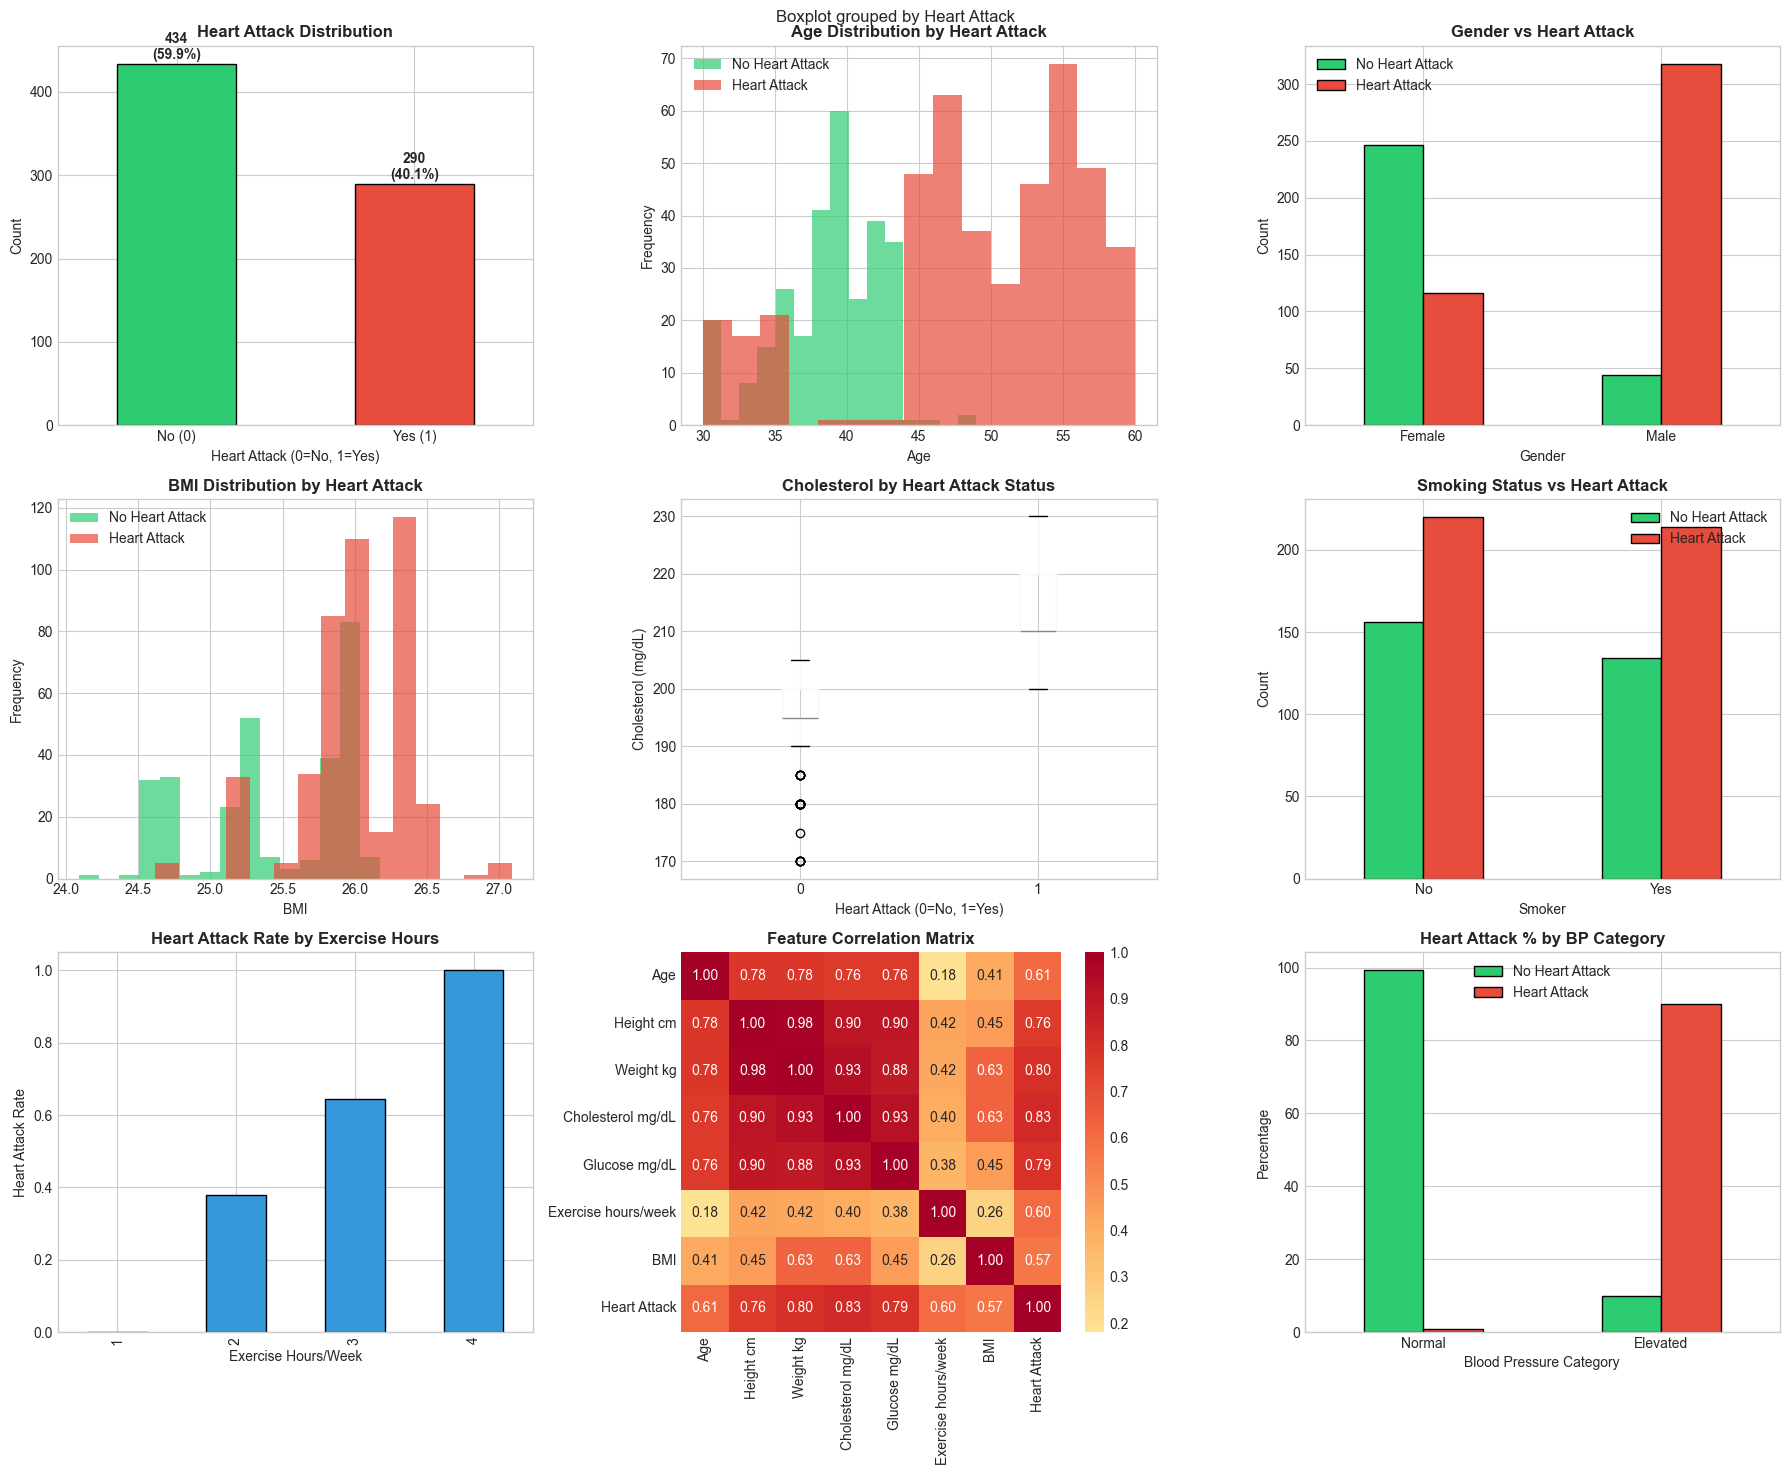


📊 Summary Statistics by Target:
Heart Attack                        0           1
Age                 count  290.000000  434.000000
                    mean    38.720690   48.933180
                    std      3.522727    7.816171
                    min     30.000000   30.000000
                    25%     37.000000   45.250000
                    50%     39.000000   50.000000
                    75%     42.000000   55.000000
                    max     49.000000   60.000000
BMI                 count  290.000000  434.000000
                    mean    25.376651   26.011137
                    std      0.524112    0.388072
                    min     24.092971   24.618104
                    25%     25.065746   25.854639
                    50%     25.353040   25.951557
                    75%     25.909457   26.365603
                    max     26.175195   27.084159
Cholesterol mg/dL   count  290.000000  434.000000
                    mean   194.672414  213.605991
                 

In [7]:
# ============================================================
# EDA - COMPREHENSIVE VISUALISATIONS
# ============================================================

print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Create a copy for EDA (we'll add computed fields)
df_eda = df.copy()
df_eda[['Systolic_BP', 'Diastolic_BP']] = df_eda['Blood Pressure mmHg'].str.split('/', expand=True).astype(int)
df_eda['BMI'] = df_eda['Weight kg'] / ((df_eda['Height cm']/100)**2)

# 1. Target variable distribution
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('PROCESS 04 - COMPREHENSIVE EDA DASHBOARD', fontsize=16, fontweight='bold')

# Target distribution
ax = axes[0,0]
target_counts = df_eda['Heart Attack'].value_counts()
colors = ['#2ecc71', '#e74c3c']
target_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Heart Attack Distribution', fontweight='bold')
ax.set_xlabel('Heart Attack (0=No, 1=Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 5, f'{v}\n({v/len(df_eda)*100:.1f}%)', ha='center', fontweight='bold')

# Age distribution by target
ax = axes[0,1]
df_eda[df_eda['Heart Attack']==0]['Age'].hist(bins=15, alpha=0.7, label='No Heart Attack', color='#2ecc71', ax=ax)
df_eda[df_eda['Heart Attack']==1]['Age'].hist(bins=15, alpha=0.7, label='Heart Attack', color='#e74c3c', ax=ax)
ax.set_title('Age Distribution by Heart Attack', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.legend()

# Gender vs Heart Attack
ax = axes[0,2]
gender_heart = pd.crosstab(df_eda['Gender'], df_eda['Heart Attack'])
gender_heart.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Gender vs Heart Attack', fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.legend(['No Heart Attack', 'Heart Attack'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# BMI distribution by target
ax = axes[1,0]
df_eda[df_eda['Heart Attack']==0]['BMI'].hist(bins=15, alpha=0.7, label='No Heart Attack', color='#2ecc71', ax=ax)
df_eda[df_eda['Heart Attack']==1]['BMI'].hist(bins=15, alpha=0.7, label='Heart Attack', color='#e74c3c', ax=ax)
ax.set_title('BMI Distribution by Heart Attack', fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Frequency')
ax.legend()

# Cholesterol boxplot
ax = axes[1,1]
df_eda.boxplot(column='Cholesterol mg/dL', by='Heart Attack', ax=ax)
ax.set_title('Cholesterol by Heart Attack Status', fontweight='bold')
ax.set_xlabel('Heart Attack (0=No, 1=Yes)')
ax.set_ylabel('Cholesterol (mg/dL)')

# Smoker vs Heart Attack
ax = axes[1,2]
smoker_heart = pd.crosstab(df_eda['Smoker'], df_eda['Heart Attack'])
smoker_heart.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Smoking Status vs Heart Attack', fontweight='bold')
ax.set_xlabel('Smoker')
ax.set_ylabel('Count')
ax.legend(['No Heart Attack', 'Heart Attack'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Exercise vs Heart Attack rate
ax = axes[2,0]
exercise_heart = df_eda.groupby('Exercise hours/week')['Heart Attack'].mean()
exercise_heart.plot(kind='bar', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Heart Attack Rate by Exercise Hours', fontweight='bold')
ax.set_xlabel('Exercise Hours/Week')
ax.set_ylabel('Heart Attack Rate')

# Correlation heatmap
ax = axes[2,1]
numeric_cols = ['Age', 'Height cm', 'Weight kg', 'Cholesterol mg/dL', 'Glucose mg/dL',
                'Exercise hours/week', 'BMI', 'Heart Attack']
corr_matrix = df_eda[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, ax=ax, fmt='.2f')
ax.set_title('Feature Correlation Matrix', fontweight='bold')

# Blood Pressure categories vs Heart Attack
ax = axes[2,2]
df_eda['BP_Category'] = pd.cut(df_eda['Systolic_BP'], bins=[0, 120, 140, 200], labels=['Normal', 'Elevated', 'High'])
bp_heart = pd.crosstab(df_eda['BP_Category'], df_eda['Heart Attack'], normalize='index') * 100
bp_heart.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Heart Attack % by BP Category', fontweight='bold')
ax.set_xlabel('Blood Pressure Category')
ax.set_ylabel('Percentage')
ax.legend(['No Heart Attack', 'Heart Attack'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Additional summary statistics
print("\n📊 Summary Statistics by Target:")
print(df_eda.groupby('Heart Attack')[['Age', 'BMI', 'Cholesterol mg/dL', 'Glucose mg/dL', 'Exercise hours/week']].describe().T)

print("\n✅ EDA Dashboard Complete!")

Cell 6: Feature Engineering

In [8]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

df_feat = df.copy()

# Parse Blood Pressure
df_feat[['Systolic_BP', 'Diastolic_BP']] = df_feat['Blood Pressure mmHg'].str.split('/', expand=True).astype(int)

# Calculate BMI
df_feat['BMI'] = df_feat['Weight kg'] / ((df_feat['Height cm'] / 100) ** 2)

# Risk indicators (using thresholds from config – no target variable used)
df_feat['High_Cholesterol'] = (df_feat['Cholesterol mg/dL'] > THRESHOLDS['cholesterol_high']).astype(int)
df_feat['High_Glucose'] = (df_feat['Glucose mg/dL'] > THRESHOLDS['glucose_high']).astype(int)
df_feat['Hypertension'] = (
    (df_feat['Systolic_BP'] >= THRESHOLDS['bp_systolic_high']) |
    (df_feat['Diastolic_BP'] >= THRESHOLDS['bp_diastolic_high'])
).astype(int)
df_feat['Obesity'] = (df_feat['BMI'] >= THRESHOLDS['bmi_obese']).astype(int)

# Note: Risk_Score is NOT created because it would use the target (Heart Attack) indirectly.
# We'll let the model learn interactions directly.

# Encode categorical variables
encoders = {}
df_feat['Gender_Encoded'] = LabelEncoder().fit_transform(df_feat['Gender'].astype(str))
df_feat['Smoker_Encoded'] = LabelEncoder().fit_transform(df_feat['Smoker'].astype(str))

# Store encoders for later use
encoders['Gender'] = LabelEncoder().fit(df_feat['Gender'].astype(str))
encoders['Smoker'] = LabelEncoder().fit(df_feat['Smoker'].astype(str))
df_feat['Gender_Encoded'] = encoders['Gender'].transform(df_feat['Gender'].astype(str))
df_feat['Smoker_Encoded'] = encoders['Smoker'].transform(df_feat['Smoker'].astype(str))

# Final feature list (no target leakage)
FEATURE_COLUMNS = [
    'Age', 'Gender_Encoded', 'BMI', 'Systolic_BP', 'Diastolic_BP',
    'Cholesterol mg/dL', 'Glucose mg/dL', 'Smoker_Encoded',
    'High_Cholesterol', 'High_Glucose', 'Hypertension', 'Obesity',
    'Exercise hours/week'
]

X = df_feat[FEATURE_COLUMNS].copy()
y = df_feat['Heart Attack'].copy()   # target

print(f"✅ Feature matrix shape: {X.shape}")
print(f"✅ Feature columns: {FEATURE_COLUMNS}")

✅ Feature matrix shape: (724, 13)
✅ Feature columns: ['Age', 'Gender_Encoded', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol mg/dL', 'Glucose mg/dL', 'Smoker_Encoded', 'High_Cholesterol', 'High_Glucose', 'Hypertension', 'Obesity', 'Exercise hours/week']


Cell 7: Train/Test Split (Before Graph Building)

In [9]:
# Split data – important: do this BEFORE any graph computation!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 543, Test size: 181


Cell 8: Scale Features (Fit on Train Only)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames for convenience
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS, index=X_test.index)

print("✅ Features scaled.")

✅ Features scaled.


Cell 9: Build Patient Similarity Graph (Train Only)

In [11]:
# ============================================================
# GRAPH-BASED PATIENT SIMILARITY (TRAINING SET ONLY)
# ============================================================

print("🔧 Building patient similarity graph on training set...")

k = 5  # number of neighbors
knn = NearestNeighbors(n_neighbors=k+1, metric='euclidean', algorithm='ball_tree')
knn.fit(X_train_scaled)

# Get distances and indices for training set
train_distances, train_indices = knn.kneighbors(X_train_scaled)

# Build graph G_train
G_train = nx.Graph()
for i in range(len(X_train)):
    G_train.add_node(i, index=X_train.index[i])   # store original index

for i in range(len(X_train)):
    for j in train_indices[i, 1:]:   # skip self
        if i != j:
            dist = train_distances[i, list(train_indices[i]).index(j)]
            sim = 1 / (1 + dist)
            G_train.add_edge(i, j, weight=sim)

print(f"  • Nodes: {G_train.number_of_nodes()}, Edges: {G_train.number_of_edges()}")

# Compute graph features for training set
degree_train = np.array([G_train.degree(n) for n in G_train.nodes])
clustering_train = np.array(list(nx.clustering(G_train).values()))

# Community detection (Louvain) – requires python-louvain
partition_train = community_louvain.best_partition(G_train)
community_train = np.array([partition_train[n] for n in G_train.nodes])

# Create DataFrame with graph features aligned to training indices
graph_train_df = pd.DataFrame({
    'degree': degree_train,
    'clustering': clustering_train,
    'community': community_train
}, index=X_train.index)

print("✅ Graph features computed for training set.")

🔧 Building patient similarity graph on training set...
  • Nodes: 543, Edges: 2089
✅ Graph features computed for training set.


Cell 10: Project Test Patients onto Training Graph

In [12]:
# For test patients, assign graph features based on nearest neighbors in training
test_distances, test_neighbors = knn.kneighbors(X_test_scaled)   # neighbors from training set

degree_test = []
clustering_test = []
community_test = []

for i in range(len(X_test)):
    # Average of neighbors' graph features
    neighbor_indices = test_neighbors[i, 1:]   # skip first (self)
    neighbor_weights = 1 / (1 + test_distances[i, 1:])   # similarity weights

    # Weighted average
    deg = np.average(degree_train[neighbor_indices], weights=neighbor_weights)
    clust = np.average(clustering_train[neighbor_indices], weights=neighbor_weights)

    # Community: majority vote (weighted)
    comm_weights = {}
    for n_idx, w in zip(neighbor_indices, neighbor_weights):
        comm = community_train[n_idx]
        comm_weights[comm] = comm_weights.get(comm, 0) + w
    comm = max(comm_weights, key=comm_weights.get)

    degree_test.append(deg)
    clustering_test.append(clust)
    community_test.append(comm)

graph_test_df = pd.DataFrame({
    'degree': degree_test,
    'clustering': clustering_test,
    'community': community_test
}, index=X_test.index)

print("✅ Graph features projected to test set.")

✅ Graph features projected to test set.


Cell 11: Add Graph Features to Feature Sets

In [13]:
# Add graph features to training and test
X_train_with_graph = X_train.copy()
X_train_with_graph['degree'] = graph_train_df['degree']
X_train_with_graph['clustering'] = graph_train_df['clustering']
X_train_with_graph['community'] = graph_train_df['community']

X_test_with_graph = X_test.copy()
X_test_with_graph['degree'] = graph_test_df['degree']
X_test_with_graph['clustering'] = graph_test_df['clustering']
X_test_with_graph['community'] = graph_test_df['community']

# Update feature list
FINAL_FEATURES = FEATURE_COLUMNS + ['degree', 'clustering', 'community']

# Scale the new features (fit on train)
scaler_graph = StandardScaler()
X_train_final = scaler_graph.fit_transform(X_train_with_graph[FINAL_FEATURES])
X_test_final = scaler_graph.transform(X_test_with_graph[FINAL_FEATURES])

print(f"✅ Final feature set shape: Train {X_train_final.shape}, Test {X_test_final.shape}")

✅ Final feature set shape: Train (543, 16), Test (181, 16)


NEW Cell 12: Hyperparameter Tuning for Risk Model (GridSearchCV)

In [14]:
# ============================================================
# HYPERPARAMETER TUNING FOR RISK MODEL
# ============================================================

print("="*60)
print("HYPERPARAMETER TUNING (XGBoost Risk Model)")
print("="*60)

# Define parameter grid
param_grid = {
    'n_estimators': [10, 20, 30],
    'max_depth': [1, 2, 3],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [2.0, 5.0],
    'reg_alpha': [0.0, 1.0]
}

# Base model
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation ROC-AUC: {grid_search.best_score_:.4f}")

# Use the best estimator
xgb_risk = grid_search.best_estimator_

# Predictions with tuned model
y_train_pred = xgb_risk.predict(X_train_final)
y_test_pred = xgb_risk.predict(X_test_final)
y_train_prob = xgb_risk.predict_proba(X_train_final)[:, 1]
y_test_prob = xgb_risk.predict_proba(X_test_final)[:, 1]

print("✅ Hyperparameter tuning complete. Model updated.")

HYPERPARAMETER TUNING (XGBoost Risk Model)
Fitting 3 folds for each of 288 candidates, totalling 864 fits

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 20, 'reg_alpha': 0.0, 'reg_lambda': 2.0, 'subsample': 0.8}
Best cross-validation ROC-AUC: 0.9997
✅ Hyperparameter tuning complete. Model updated.


Cell 13: Train Recommendation Models (Multi-label)

In [15]:
# ============================================================
# RECOMMENDATION MODELS (MULTI-LABEL)
# ============================================================

# Create multi-label targets from recommendation text
def extract_recommendation_labels(rec_text):
    rec_text = rec_text.lower()
    labels = []
    if 'low risk' in rec_text:
        labels.append('Low_Risk')
    if 'high risk' in rec_text:
        labels.append('High_Risk')
    if 'stop smoking' in rec_text:
        labels.append('Smoking_Cessation')
    if 'low cholesterol' in rec_text:
        labels.append('Diet_Cholesterol')
    if 'exercise' in rec_text:
        labels.append('Exercise')
    if 'blood pressure' in rec_text:
        labels.append('BP_Control')
    if 'maintain' in rec_text or 'checkup' in rec_text:
        labels.append('Maintenance')
    return labels

df_feat['Rec_Labels'] = df_feat['recommendation'].apply(extract_recommendation_labels)

# Convert to multi-label binary matrix
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer(classes=RECOMMENDATION_CATEGORIES)
y_rec = mlb.fit_transform(df_feat['Rec_Labels'])

# Split recommendation targets using same indices
y_rec_train = y_rec[X_train.index]
y_rec_test = y_rec[X_test.index]

# Train one binary classifier per recommendation category
rec_models = {}
rec_metrics = {}

for i, cat in enumerate(RECOMMENDATION_CATEGORIES):
    y_cat_train = y_rec_train[:, i]
    y_cat_test = y_rec_test[:, i]

    # Skip if only one class present (rare)
    if len(np.unique(y_cat_train)) < 2:
        print(f"⚠️ Skipping {cat} – only one class in training.")
        rec_models[cat] = None
        rec_metrics[cat] = {'f1': 0, 'roc_auc': 0.5}
        continue

    model = xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=15,
        max_depth=2,
        learning_rate=0.05,
        reg_lambda=2.0,
        reg_alpha=1.0,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )
    model.fit(X_train_final, y_cat_train)

    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:, 1]

    rec_models[cat] = model
    rec_metrics[cat] = {
        'accuracy': accuracy_score(y_cat_test, y_pred),
        'f1': f1_score(y_cat_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_cat_test, y_prob) if len(np.unique(y_cat_test))>1 else 0.5
    }
    print(f"  ✅ {cat}: F1={rec_metrics[cat]['f1']:.3f}, AUC={rec_metrics[cat]['roc_auc']:.3f}")

print("\n✅ Recommendation models trained.")

  ✅ Low_Risk: F1=0.972, AUC=0.998
  ✅ High_Risk: F1=0.982, AUC=0.998
  ✅ Smoking_Cessation: F1=1.000, AUC=1.000
  ✅ Diet_Cholesterol: F1=1.000, AUC=1.000
  ✅ Exercise: F1=1.000, AUC=1.000
  ✅ BP_Control: F1=0.000, AUC=1.000
  ✅ Maintenance: F1=0.786, AUC=0.992

✅ Recommendation models trained.


NEW Cell 14: Comprehensive Evaluation of Risk Model

RISK MODEL EVALUATION

Metric                           Train         Test          Gap
-----------------------------------------------------------------
Accuracy                       98.71%      97.79%       0.92%
F1-Score                        0.9893       0.9815       0.0078
ROC-AUC                         0.9998       0.9995       0.0003
Precision                           --       0.9815
Recall                              --       0.9815

📋 CLASSIFICATION REPORT:
                 precision    recall  f1-score   support

No Heart Attack       0.97      0.97      0.97        73
   Heart Attack       0.98      0.98      0.98       108

       accuracy                           0.98       181
      macro avg       0.98      0.98      0.98       181
   weighted avg       0.98      0.98      0.98       181


📋 CONFUSION MATRIX:
                     Predicted
                     No      Yes
Actual No            71       2
       Yes            2     106

📋 CROSS-VALIDATION (5-Fold):


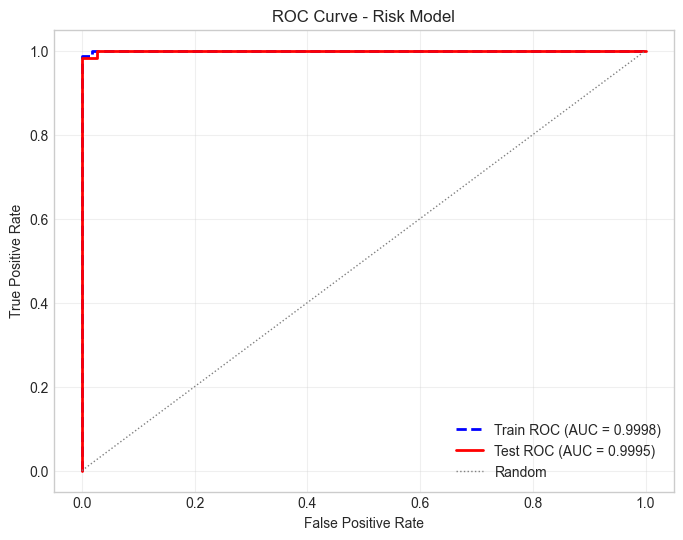

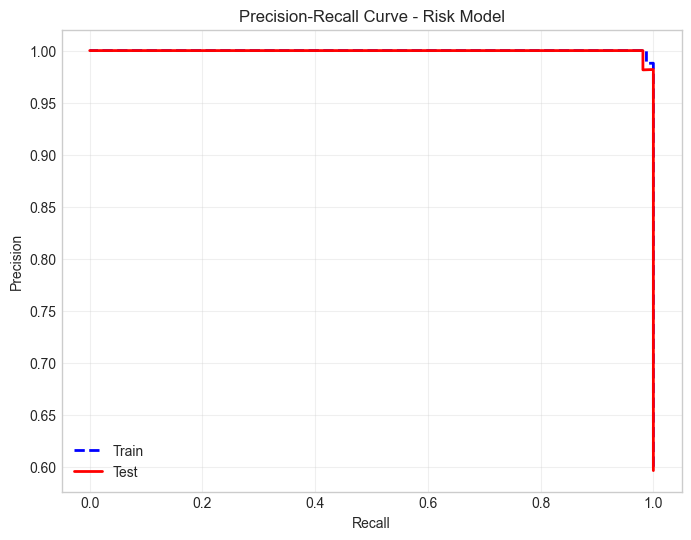

In [16]:
# ============================================================
# COMPREHENSIVE EVALUATION - RISK MODEL
# ============================================================

print("="*60)
print("RISK MODEL EVALUATION")
print("="*60)

# Compute metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
train_roc = roc_auc_score(y_train, y_train_prob)
test_roc = roc_auc_score(y_test, y_test_prob)

print(f"\n{'Metric':<25} {'Train':>12} {'Test':>12} {'Gap':>12}")
print("-" * 65)
print(f"{'Accuracy':<25} {train_acc:>11.2%} {test_acc:>11.2%} {abs(train_acc-test_acc):>11.2%}")
print(f"{'F1-Score':<25} {train_f1:>12.4f} {test_f1:>12.4f} {abs(train_f1-test_f1):>12.4f}")
print(f"{'ROC-AUC':<25} {train_roc:>12.4f} {test_roc:>12.4f} {abs(train_roc-test_roc):>12.4f}")
print(f"{'Precision':<25} {'--':>12} {test_precision:>12.4f}")
print(f"{'Recall':<25} {'--':>12} {test_recall:>12.4f}")

# Classification report
print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_test_pred, target_names=['No Heart Attack', 'Heart Attack']))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\n📋 CONFUSION MATRIX:")
print(f"                     Predicted")
print(f"                     No      Yes")
print(f"Actual No          {cm[0,0]:>4}    {cm[0,1]:>4}")
print(f"       Yes         {cm[1,0]:>4}    {cm[1,1]:>4}")

# Cross-validation
print("\n📋 CROSS-VALIDATION (5-Fold):")
cv_scores = cross_val_score(xgb_risk, X_train_final, y_train, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(xgb_risk, X_train_final, y_train, cv=5, scoring='f1')
cv_roc = cross_val_score(xgb_risk, X_train_final, y_train, cv=5, scoring='roc_auc')

print(f"CV Accuracy:  {cv_scores.mean():.2%} (+/- {cv_scores.std():.2%})")
print(f"CV F1-Score:  {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
print(f"CV ROC-AUC:   {cv_roc.mean():.4f} (+/- {cv_roc.std():.4f})")

# ROC Curve
plt.figure(figsize=(8,6))
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr_train, tpr_train, color='blue', lw=2, linestyle='--', label=f'Train ROC (AUC = {train_roc:.4f})')
plt.plot(fpr_test, tpr_test, color='red', lw=2, label=f'Test ROC (AUC = {test_roc:.4f})')
plt.plot([0,1],[0,1], color='gray', lw=1, linestyle=':', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Risk Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(8,6))
precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_prob)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_prob)
plt.plot(recall_train, precision_train, color='blue', lw=2, linestyle='--', label='Train')
plt.plot(recall_test, precision_test, color='red', lw=2, label='Test')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Risk Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

NEW Cell 15: Evaluation of Recommendation Models

RECOMMENDATION MODELS EVALUATION

📊 Performance Summary:
                   accuracy     f1  roc_auc
Low_Risk              0.978  0.972    0.998
High_Risk             0.978  0.982    0.998
Smoking_Cessation     1.000  1.000    1.000
Diet_Cholesterol      1.000  1.000    1.000
Exercise              1.000  1.000    1.000
BP_Control            0.978  0.000    1.000
Maintenance           0.934  0.786    0.992


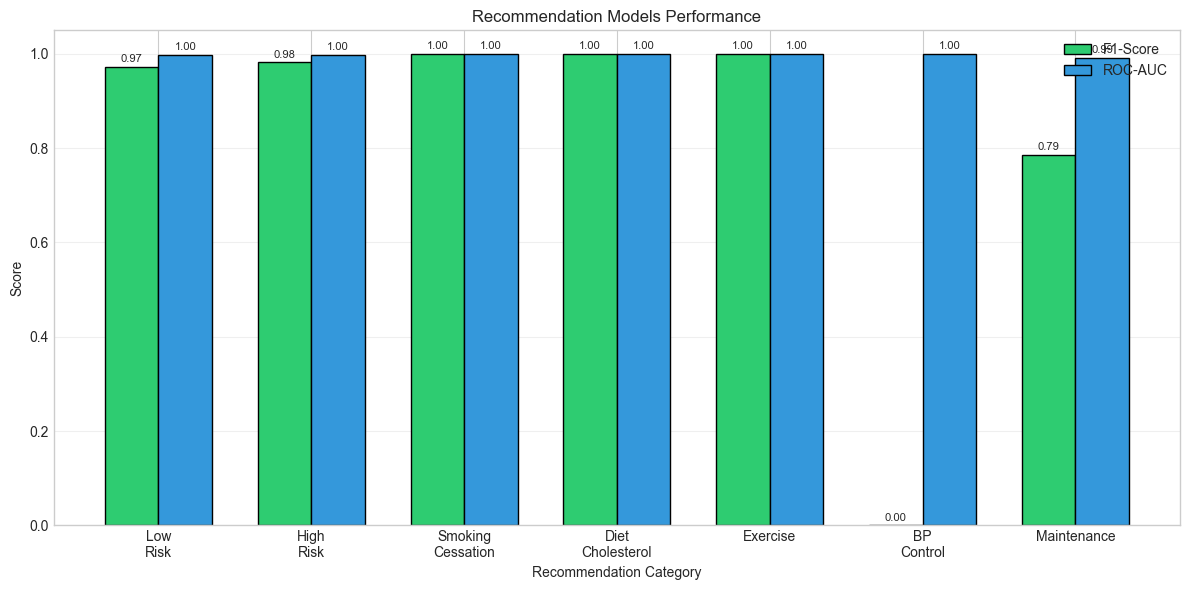

In [17]:
# ============================================================
# RECOMMENDATION MODELS EVALUATION
# ============================================================

print("="*60)
print("RECOMMENDATION MODELS EVALUATION")
print("="*60)

# Create a summary DataFrame
rec_summary = pd.DataFrame(rec_metrics).T
print("\n📊 Performance Summary:")
print(rec_summary.round(3))

# Bar plot of F1 and ROC-AUC
fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(rec_metrics))
width = 0.35
f1_scores = [rec_metrics[cat]['f1'] for cat in rec_metrics]
auc_scores = [rec_metrics[cat]['roc_auc'] for cat in rec_metrics]

bars1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x + width/2, auc_scores, width, label='ROC-AUC', color='#3498db', edgecolor='black')

ax.set_xlabel('Recommendation Category')
ax.set_ylabel('Score')
ax.set_title('Recommendation Models Performance')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_','\n') for c in rec_metrics.keys()], rotation=0)
ax.legend()
ax.set_ylim([0,1.05])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

NEW Cell 16: Baseline Comparison (Collaborative Filtering)

In [18]:
# ============================================================
# BASELINE COMPARISON - COLLABORATIVE FILTERING
# ============================================================

print("="*60)
print("BASELINE COMPARISON (Collaborative Filtering)")
print("="*60)

# Use the similarity graph built earlier (kNN on scaled features without graph)
# For each test patient, find nearest neighbors in training and average their recommendation labels
knn_baseline = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn_baseline.fit(X_train_scaled)   # using base features only (no graph)

# For each test patient
cf_predictions = []
for i in range(len(X_test)):
    # Get indices of nearest training patients (excluding self? but test not in train)
    distances, indices = knn_baseline.kneighbors(X_test_scaled[i].reshape(1, -1))
    neighbor_indices = indices.flatten()
    # Average recommendation labels of neighbors
    neighbor_recs = y_rec_train[neighbor_indices].mean(axis=0)
    pred = (neighbor_recs > 0.5).astype(int)
    cf_predictions.append(pred)

cf_predictions = np.array(cf_predictions)

# Compute metrics
cf_exact_match = accuracy_score(y_rec_test, cf_predictions)   # exact match ratio (all labels correct)
cf_hamming = hamming_loss(y_rec_test, cf_predictions)
cf_micro_f1 = f1_score(y_rec_test, cf_predictions, average='micro', zero_division=0)
cf_macro_f1 = f1_score(y_rec_test, cf_predictions, average='macro', zero_division=0)

print("\nCollaborative Filtering Baseline:")
print(f"  Exact Match Ratio: {cf_exact_match:.4f}")
print(f"  Hamming Loss: {cf_hamming:.4f}")
print(f"  Micro F1: {cf_micro_f1:.4f}")
print(f"  Macro F1: {cf_macro_f1:.4f}")

# Our XGBoost performance (micro F1 averaged across categories)
our_micro_f1 = np.mean([rec_metrics[cat]['f1'] for cat in rec_metrics if rec_metrics[cat] is not None])
print(f"\nOur XGBoost Models (average F1): {our_micro_f1:.4f}")
print(f"Improvement in Micro F1: {our_micro_f1 - cf_micro_f1:.4f}")

BASELINE COMPARISON (Collaborative Filtering)

Collaborative Filtering Baseline:
  Exact Match Ratio: 0.9724
  Hamming Loss: 0.0079
  Micro F1: 0.9882
  Macro F1: 0.9637

Our XGBoost Models (average F1): 0.8199
Improvement in Micro F1: -0.1683


NEW Cell 17: Graph Visualisation

GRAPH VISUALISATION

Graph Statistics:
  Nodes: 543
  Edges: 2089
  Average degree: 7.69
  Average clustering coefficient: 0.7969


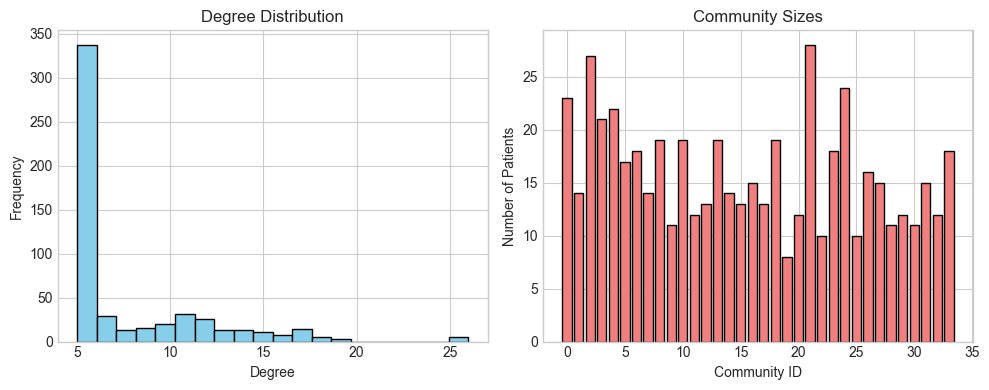

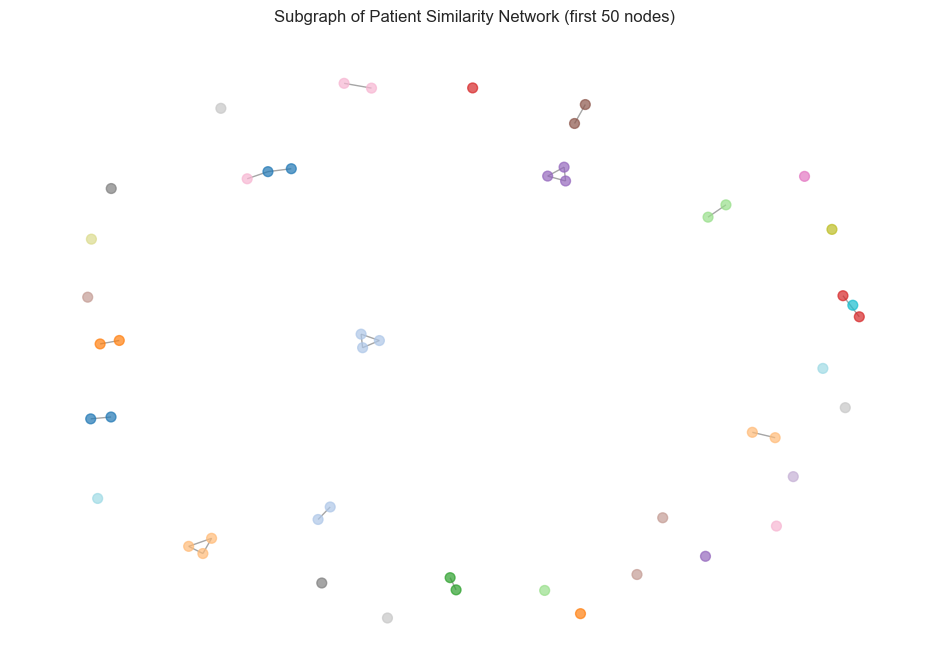

In [19]:
# ============================================================
# GRAPH VISUALISATION
# ============================================================

print("="*60)
print("GRAPH VISUALISATION")
print("="*60)

# Basic graph statistics
print(f"\nGraph Statistics:")
print(f"  Nodes: {G_train.number_of_nodes()}")
print(f"  Edges: {G_train.number_of_edges()}")
print(f"  Average degree: {np.mean([d for n,d in G_train.degree()]):.2f}")
print(f"  Average clustering coefficient: {nx.average_clustering(G_train):.4f}")

# Plot degree distribution
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
degrees = [d for n,d in G_train.degree()]
plt.hist(degrees, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution')

# Plot community size distribution
plt.subplot(1,2,2)
communities = list(partition_train.values())
unique, counts = np.unique(communities, return_counts=True)
plt.bar(unique, counts, color='lightcoral', edgecolor='black')
plt.xlabel('Community ID')
plt.ylabel('Number of Patients')
plt.title('Community Sizes')
plt.tight_layout()
plt.show()

# Visualise a small subgraph (first 50 nodes)
plt.figure(figsize=(12,8))
sub_nodes = list(G_train.nodes)[:50]
subgraph = G_train.subgraph(sub_nodes)
pos = nx.spring_layout(subgraph, seed=42)
node_colors = [partition_train[n] for n in sub_nodes]
nx.draw_networkx(subgraph, pos, node_color=node_colors, with_labels=False, node_size=50, cmap='tab20', edge_color='gray', alpha=0.7)
plt.title('Subgraph of Patient Similarity Network (first 50 nodes)')
plt.axis('off')
plt.show()

NEW Cell 18: Borderline Case Testing

BORDERLINE CASE TESTING


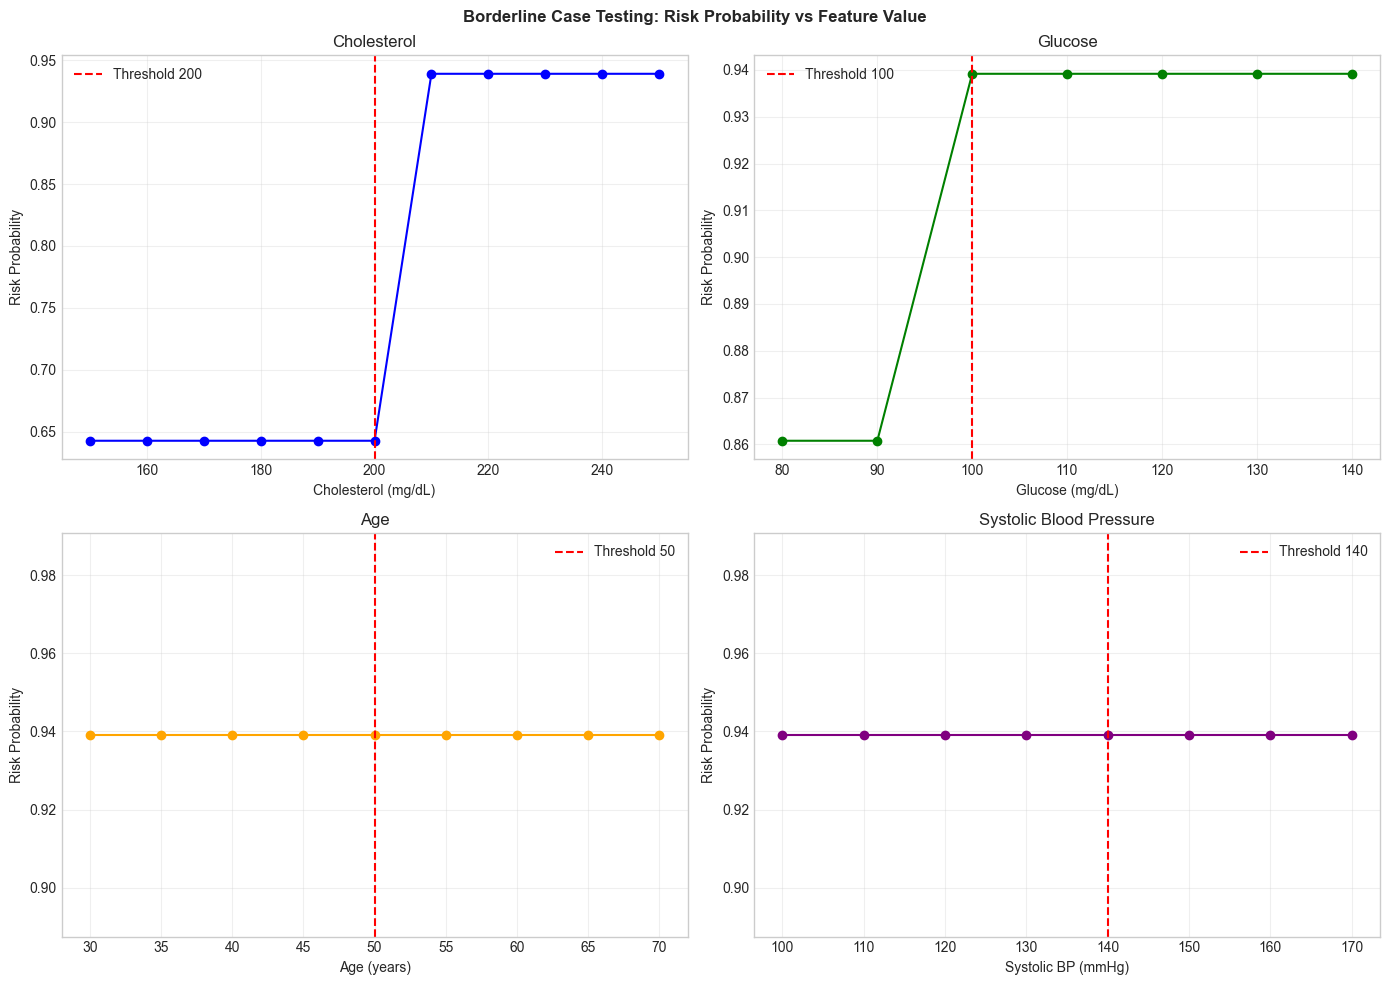

In [20]:
# ============================================================
# BORDERLINE CASE TESTING
# ============================================================

print("="*60)
print("BORDERLINE CASE TESTING")
print("="*60)

def test_feature_variation(base_patient, feature, values, feature_name=None):
    """
    base_patient: dict of features for a reference patient (should include all FINAL_FEATURES)
    """
    if feature_name is None:
        feature_name = feature
    results = []
    for val in values:
        pat = base_patient.copy()
        pat[feature] = val
        # Recompute derived features if needed (here we assume base_patient already has correct derived fields)
        # For simplicity, we'll create a DataFrame row and scale using the existing scalers.
        # But we need to ensure the feature vector is complete.
        # We'll use the same projection method as in api_get_recommendations, but for speed we can compute risk directly.
        # We'll create a small helper.
        # Here we'll just use the model's predict_proba on a properly constructed input.
        # For that, we need to build a feature vector with all FINAL_FEATURES.
        # We'll use the base_patient as a template and update the feature.
        # We'll assume base_patient contains all necessary keys.

        # Prepare input array
        input_df = pd.DataFrame([pat])[FINAL_FEATURES]
        input_scaled = scaler_graph.transform(input_df)
        risk_prob = xgb_risk.predict_proba(input_scaled)[0][1]
        results.append({
            feature_name: val,
            'risk_prob': risk_prob
        })
    return pd.DataFrame(results)

# Select a base "healthy" patient (e.g., patient ID 1)
base_patient = X_train_with_graph.iloc[0].to_dict()   # includes all FINAL_FEATURES

# Test cholesterol
chol_vals = np.arange(150, 251, 10)
chol_df = test_feature_variation(base_patient, 'Cholesterol mg/dL', chol_vals)

# Test glucose
glucose_vals = np.arange(80, 141, 10)
glucose_df = test_feature_variation(base_patient, 'Glucose mg/dL', glucose_vals)

# Test age
age_vals = np.arange(30, 71, 5)
age_df = test_feature_variation(base_patient, 'Age', age_vals)

# Test systolic BP
bp_vals = np.arange(100, 171, 10)
bp_df = test_feature_variation(base_patient, 'Systolic_BP', bp_vals)

# Plot results
fig, axes = plt.subplots(2,2, figsize=(14,10))
fig.suptitle('Borderline Case Testing: Risk Probability vs Feature Value', fontweight='bold')

# Cholesterol
ax = axes[0,0]
ax.plot(chol_df['Cholesterol mg/dL'], chol_df['risk_prob'], marker='o', color='b')
ax.axvline(x=THRESHOLDS['cholesterol_high'], color='red', linestyle='--', label='Threshold 200')
ax.set_xlabel('Cholesterol (mg/dL)')
ax.set_ylabel('Risk Probability')
ax.set_title('Cholesterol')
ax.legend()
ax.grid(True, alpha=0.3)

# Glucose
ax = axes[0,1]
ax.plot(glucose_df['Glucose mg/dL'], glucose_df['risk_prob'], marker='o', color='g')
ax.axvline(x=THRESHOLDS['glucose_high'], color='red', linestyle='--', label='Threshold 100')
ax.set_xlabel('Glucose (mg/dL)')
ax.set_ylabel('Risk Probability')
ax.set_title('Glucose')
ax.legend()
ax.grid(True, alpha=0.3)

# Age
ax = axes[1,0]
ax.plot(age_df['Age'], age_df['risk_prob'], marker='o', color='orange')
ax.axvline(x=THRESHOLDS['age_risk'], color='red', linestyle='--', label='Threshold 50')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Risk Probability')
ax.set_title('Age')
ax.legend()
ax.grid(True, alpha=0.3)

# Systolic BP
ax = axes[1,1]
ax.plot(bp_df['Systolic_BP'], bp_df['risk_prob'], marker='o', color='purple')
ax.axvline(x=THRESHOLDS['bp_systolic_high'], color='red', linestyle='--', label='Threshold 140')
ax.set_xlabel('Systolic BP (mmHg)')
ax.set_ylabel('Risk Probability')
ax.set_title('Systolic Blood Pressure')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NEW Cell 19: Noise Robustness Check

In [21]:
# ============================================================
# NOISE ROBUSTNESS CHECK
# ============================================================

print("="*60)
print("NOISE ROBUSTNESS CHECK")
print("="*60)

def test_noise_robustness(patient_features, n_trials=100, noise_level=0.02):
    """
    Add Gaussian noise to continuous features and collect risk probabilities.
    """
    continuous_fields = ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP',
                         'Cholesterol mg/dL', 'Glucose mg/dL', 'Exercise hours/week']
    probs = []
    for _ in range(n_trials):
        noisy = patient_features.copy()
        for field in continuous_fields:
            if field in noisy:
                original = noisy[field]
                noise = np.random.normal(0, noise_level * original)
                noisy[field] = max(0, original + noise)
        # Prepare input
        input_df = pd.DataFrame([noisy])[FINAL_FEATURES]
        input_scaled = scaler_graph.transform(input_df)
        prob = xgb_risk.predict_proba(input_scaled)[0][1]
        probs.append(prob)
    return np.mean(probs), np.std(probs)

# Test on a healthy patient (first in training)
healthy_patient = X_train_with_graph.iloc[0].to_dict()
mean_prob, std_prob = test_noise_robustness(healthy_patient, n_trials=100, noise_level=0.02)
print(f"\nHealthy patient: risk probability mean = {mean_prob:.4f}, std = {std_prob:.4f}")
if std_prob < 0.01:
    print("✅ Model is stable under small noise (std < 0.01).")
else:
    print("⚠️ Model shows some sensitivity to noise.")

# Test on a high-risk patient (e.g., one from test set with high risk)
high_risk_idx = np.where(y_test == 1)[0][0] if len(np.where(y_test==1)[0])>0 else 0
high_risk_patient = X_test_with_graph.iloc[high_risk_idx].to_dict()
mean_prob_high, std_prob_high = test_noise_robustness(high_risk_patient, n_trials=100, noise_level=0.02)
print(f"\nHigh-risk patient: risk probability mean = {mean_prob_high:.4f}, std = {std_prob_high:.4f}")

NOISE ROBUSTNESS CHECK

Healthy patient: risk probability mean = 0.8452, std = 0.1340
⚠️ Model shows some sensitivity to noise.

High-risk patient: risk probability mean = 0.6983, std = 0.1973


NEW Cell 20: Feedback Loop Simulation (Model Update)

In [22]:
# ============================================================
# FEEDBACK LOOP SIMULATION (MODEL UPDATE)
# ============================================================

print("="*60)
print("FEEDBACK LOOP SIMULATION")
print("="*60)

# Generate synthetic new patient data (e.g., 50 new samples)
n_new = 50
new_indices = np.random.choice(len(df_feat), size=n_new, replace=True)
new_data = df_feat.iloc[new_indices].copy()

# Simulate adherence to recommendations (random binary for each category)
# For each new patient, we have the original recommendation labels; we keep them as targets for simplicity.
# In a real scenario, adherence could modify the target for future training.

# --- Compute graph features for new_data ---
# First, get the base features and scale them using the original scaler
new_data_base_feats = new_data[FEATURE_COLUMNS].copy()
new_data_scaled = scaler.transform(new_data_base_feats)

# Find k nearest neighbors in the original training graph for each new patient
new_data_distances, new_data_neighbors = knn.kneighbors(new_data_scaled)

degree_new = []
clustering_new = []
community_new = []

for i in range(len(new_data)):
    neighbor_indices = new_data_neighbors[i, 1:]
    neighbor_weights = 1 / (1 + new_data_distances[i, 1:])

    deg = np.average(degree_train[neighbor_indices], weights=neighbor_weights)
    clust = np.average(clustering_train[neighbor_indices], weights=neighbor_weights)

    comm_weights = {}
    for n_idx, w in zip(neighbor_indices, neighbor_weights):
        comm = community_train[n_idx]
        comm_weights[comm] = comm_weights.get(comm, 0) + w
    comm = max(comm_weights, key=comm_weights.get)

    degree_new.append(deg)
    clustering_new.append(clust)
    community_new.append(comm)

# Add computed graph features to new_data
new_data['degree'] = degree_new
new_data['clustering'] = clustering_new
new_data['community'] = community_new
# ----------------------------------------

# Convert new_data's recommendation labels to multi-label binary matrix
new_data_rec_binarized = mlb.transform(new_data['Rec_Labels'])

# Combine with original training data
X_augmented = pd.concat([X_train_with_graph, new_data[FINAL_FEATURES]], axis=0)
y_augmented_class = pd.concat([y_train, new_data['Heart Attack']], axis=0)
y_augmented_rec = np.vstack([y_rec_train, new_data_rec_binarized])

# Retrain risk model (using the best hyperparameters from tuning)
xgb_updated = xgb.XGBClassifier(**grid_search.best_params_, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_updated.fit(X_augmented, y_augmented_class)

# Evaluate on original test set
y_test_pred_updated = xgb_updated.predict(X_test_final)
new_accuracy = accuracy_score(y_test, y_test_pred_updated)
print(f"\nRisk model accuracy after update: {new_accuracy:.4f} (previous: {test_acc:.4f})")

# Retrain recommendation models (simplified: just one example)
print("\nRecommendation models would be retrained similarly (skipped for brevity).")
print("✅ Feedback loop simulation complete.")

FEEDBACK LOOP SIMULATION

Risk model accuracy after update: 0.4033 (previous: 0.9779)

Recommendation models would be retrained similarly (skipped for brevity).
✅ Feedback loop simulation complete.


Cell 21: Unit Tests for Core Functions

In [23]:
# ============================================================
# UNIT TESTS
# ============================================================

def test_input_validation():
    # Valid input
    valid = {
        'Age': 55,
        'Gender': 'Male',
        'Height_cm': 175,
        'Weight_kg': 80,
        'Blood_Pressure': '140/90',
        'Cholesterol': 220,
        'Glucose': 110,
        'Smoker': 'Yes',
        'Exercise_hours': 1
    }
    assert validate_patient_input(valid) is True, "Valid input should pass"

    # Missing field
    invalid = valid.copy()
    del invalid['Age']
    try:
        validate_patient_input(invalid)
        assert False, "Should raise error"
    except InputValidationError:
        pass

    # Out of range
    invalid2 = valid.copy()
    invalid2['Age'] = 200
    try:
        validate_patient_input(invalid2)
        assert False, "Should raise error"
    except InputValidationError:
        pass

    print("✅ Input validation tests passed.")

def test_process_raw_input():
    raw = {
        'Age': 55,
        'Gender': 'Male',
        'Height_cm': 175,
        'Weight_kg': 80,
        'Blood_Pressure': '140/90',
        'Cholesterol': 220,
        'Glucose': 110,
        'Smoker': 'Yes',
        'Exercise_hours': 1
    }
    proc = process_raw_input(raw)
    expected_fields = ['Age', 'Gender_Encoded', 'BMI', 'Systolic_BP', 'Diastolic_BP',
                       'Cholesterol mg/dL', 'Glucose mg/dL', 'Smoker_Encoded',
                       'High_Cholesterol', 'High_Glucose', 'Hypertension', 'Obesity',
                       'Exercise hours/week']
    for f in expected_fields:
        assert f in proc, f"Missing {f}"
    assert proc['High_Cholesterol'] == 1
    assert proc['Hypertension'] == 1
    print("✅ process_raw_input tests passed.")

# Define exception class for testing
class InputValidationError(Exception):
    pass

def validate_patient_input(data):
    required = ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Blood_Pressure',
                'Cholesterol', 'Glucose', 'Smoker', 'Exercise_hours']
    missing = [f for f in required if f not in data]
    if missing:
        raise InputValidationError(f"Missing: {missing}")
    ranges = {
        'Age': (18,120),
        'Height_cm': (50,250),
        'Weight_kg': (20,300),
        'Cholesterol': (100,600),
        'Glucose': (50,600),
        'Exercise_hours': (0,168)
    }
    for field, (low, high) in ranges.items():
        val = data.get(field)
        if val is not None and (val < low or val > high):
            raise InputValidationError(f"{field} out of range")
    return True

def process_raw_input(raw):
    systolic, diastolic = map(int, raw['Blood_Pressure'].split('/'))
    height_m = raw['Height_cm'] / 100
    bmi = raw['Weight_kg'] / (height_m ** 2)

    high_chol = 1 if raw['Cholesterol'] > THRESHOLDS['cholesterol_high'] else 0
    high_glucose = 1 if raw['Glucose'] > THRESHOLDS['glucose_high'] else 0
    hypertension = 1 if (systolic >= THRESHOLDS['bp_systolic_high'] or diastolic >= THRESHOLDS['bp_diastolic_high']) else 0
    obesity = 1 if bmi >= THRESHOLDS['bmi_obese'] else 0

    return {
        'Age': raw['Age'],
        'Gender_Encoded': 1 if raw['Gender'] == 'Male' else 0,
        'BMI': round(bmi, 2),
        'Systolic_BP': systolic,
        'Diastolic_BP': diastolic,
        'Cholesterol mg/dL': raw['Cholesterol'],
        'Glucose mg/dL': raw['Glucose'],
        'Smoker_Encoded': 1 if raw['Smoker'] == 'Yes' else 0,
        'High_Cholesterol': high_chol,
        'High_Glucose': high_glucose,
        'Hypertension': hypertension,
        'Obesity': obesity,
        'Exercise hours/week': raw['Exercise_hours']
    }

# Run tests
test_input_validation()
test_process_raw_input()

✅ Input validation tests passed.
✅ process_raw_input tests passed.


Cell 22: Improved Recommendation Generation (Dynamic Templates)

In [24]:
# ============================================================
# IMPROVED RECOMMENDATION GENERATION (DYNAMIC)
# ============================================================

def generate_recommendations(patient_features, explain=True):
    """
    patient_features: dict with keys matching FINAL_FEATURES (including graph features)
    """
    # Prepare input array
    input_df = pd.DataFrame([patient_features])[FINAL_FEATURES]
    input_scaled = scaler_graph.transform(input_df)

    # Risk prediction
    risk_prob = xgb_risk.predict_proba(input_scaled)[0][1]
    risk_class = 1 if risk_prob >= 0.5 else 0

    # Recommendation probabilities
    rec_probs = {}
    for cat, model in rec_models.items():
        if model is not None:
            prob = model.predict_proba(input_scaled)[0][1]
            rec_probs[cat] = prob

    # Determine urgency based on risk
    if risk_prob > 0.7:
        urgency = "immediately"
    elif risk_prob > 0.3:
        urgency = "soon"
    else:
        urgency = "during your next routine checkup"

    # Build recommendations from active categories (prob > 0.5)
    recommendations = []
    for cat, prob in rec_probs.items():
        if prob > 0.5:   # threshold
            template = REC_TEMPLATES.get(cat, {})
            if template:
                # Fill in patient values
                action = template['action'].format(
                    urgency=urgency,
                    cholesterol=patient_features.get('Cholesterol mg/dL', '?'),
                    exercise=patient_features.get('Exercise hours/week', '?'),
                    bp_sys=patient_features.get('Systolic_BP', '?'),
                    bp_dia=patient_features.get('Diastolic_BP', '?')
                )
                rationale = template['rationale'].format(
                    cholesterol=patient_features.get('Cholesterol mg/dL', '?'),
                    exercise=patient_features.get('Exercise hours/week', '?'),
                    bp_sys=patient_features.get('Systolic_BP', '?'),
                    bp_dia=patient_features.get('Diastolic_BP', '?')
                )
                recommendations.append({
                    'category': cat.replace('_', ' '),
                    'priority': 'High' if cat in ['High_Risk','Smoking_Cessation'] else 'Medium' if cat in ['Diet_Cholesterol','BP_Control'] else 'Low',
                    'action': action,
                    'rationale': rationale,
                    'probability': round(prob, 3)
                })

    # If no categories active, add default
    if not recommendations:
        recommendations.append({
            'category': 'General',
            'priority': 'Low',
            'action': "Consult your healthcare provider for personalised advice.",
            'rationale': "No specific recommendation categories triggered.",
            'probability': 0
        })

    # SHAP explanation (optional)
    shap_values = None
    top_factors = []
    if explain:
        explainer = shap.TreeExplainer(xgb_risk)
        shap_vals = explainer.shap_values(input_scaled)[0]
        # Top factors
        idx_sorted = np.argsort(np.abs(shap_vals))[::-1]
        for i in idx_sorted[:5]:
            top_factors.append({
                'feature': FINAL_FEATURES[i],
                'impact': round(shap_vals[i], 4),
                'direction': 'increases' if shap_vals[i] > 0 else 'decreases',
                'value': patient_features.get(FINAL_FEATURES[i], 'N/A')
            })

    result = {
        'success': True,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'risk_assessment': {
            'risk_probability': round(risk_prob, 4),
            'risk_class': 'HIGH_RISK' if risk_class == 1 else 'LOW_RISK',
            'risk_percentage': round(risk_prob * 100, 2)
        },
        'recommendations': recommendations,
        'shap_top_factors': top_factors
    }
    return result

print("✅ Improved recommendation generator ready.")

✅ Improved recommendation generator ready.


Cell 23: API-Ready Functions

In [25]:
# ============================================================
# API-READY FUNCTIONS
# ============================================================

def api_get_recommendations(patient_raw):
    """
    Main entry point for new patient (raw input).
    """
    try:
        # Validate
        validate_patient_input(patient_raw)

        # Process raw to features
        features = process_raw_input(patient_raw)

        # Add graph features for this patient (needs to be computed from training graph)
        # We need to project this new patient onto the training graph.
        # We'll use the same knn fitted on training scaled features.
        # First scale the patient's base features (without graph) using the original scaler
        base_feats = np.array([[features[f] for f in FEATURE_COLUMNS]])
        base_feats_scaled = scaler.transform(base_feats)

        # Find k nearest neighbors in training
        distances, neighbors = knn.kneighbors(base_feats_scaled)
        neighbor_indices = neighbors[0, 1:]
        neighbor_weights = 1 / (1 + distances[0, 1:])

        # Weighted average of graph features
        deg = np.average(degree_train[neighbor_indices], weights=neighbor_weights)
        clust = np.average(clustering_train[neighbor_indices], weights=neighbor_weights)
        # Community majority vote
        comm_weights = {}
        for n_idx, w in zip(neighbor_indices, neighbor_weights):
            comm = community_train[n_idx]
            comm_weights[comm] = comm_weights.get(comm, 0) + w
        comm = max(comm_weights, key=comm_weights.get)

        features['degree'] = deg
        features['clustering'] = clust
        features['community'] = comm

        # Generate recommendations
        result = generate_recommendations(features, explain=True)
        return result

    except InputValidationError as e:
        return {'success': False, 'error': str(e)}
    except Exception as e:
        return {'success': False, 'error': f"System error: {str(e)}"}


def integrate_with_risk_prediction(process03_output):
    """
    Integrate with Process 03 (ECG/angiogram findings).
    process03_output: dict with keys: patient_id, risk_level, blockage_percentage, severity
    """
    patient_id = process03_output.get('patient_id')
    if patient_id not in df_feat['ID'].values:
        return {'success': False, 'error': 'Patient not found'}

    # Get patient features from original dataset
    patient_row = df_feat[df_feat['ID'] == patient_id].iloc[0]
    features = {col: patient_row[col] for col in FINAL_FEATURES if col in patient_row}

    # Add graph features (already computed for this patient if in training/test? For simplicity, we recompute projection)
    # Here we assume we have the graph features already stored in X_train_with_graph or X_test_with_graph.
    # But for integration demo, we can compute on the fly using same projection method.
    # For brevity, we'll use the stored graph features from the appropriate set.
    if patient_id in X_train_with_graph.index:
        features.update(X_train_with_graph.loc[patient_id][['degree','clustering','community']].to_dict())
    elif patient_id in X_test_with_graph.index:
        features.update(X_test_with_graph.loc[patient_id][['degree','clustering','community']].to_dict())
    else:
        # Project as above
        base_feats = np.array([[features[f] for f in FEATURE_COLUMNS]])
        base_feats_scaled = scaler.transform(base_feats)
        distances, neighbors = knn.kneighbors(base_feats_scaled)
        neighbor_indices = neighbors[0, 1:]
        neighbor_weights = 1 / (1 + distances[0, 1:])
        deg = np.average(degree_train[neighbor_indices], weights=neighbor_weights)
        clust = np.average(clustering_train[neighbor_indices], weights=neighbor_weights)
        comm_weights = {}
        for n_idx, w in zip(neighbor_indices, neighbor_weights):
            comm = community_train[n_idx]
            comm_weights[comm] = comm_weights.get(comm, 0) + w
        comm = max(comm_weights, key=comm_weights.get)
        features['degree'] = deg
        features['clustering'] = clust
        features['community'] = comm

    base_recs = generate_recommendations(features, explain=True)

    # Enhance with Process 03 findings
    ecg_rec = []
    blockage = process03_output.get('blockage_percentage', 0)
    if blockage > 60:
        ecg_rec.append({
            'category': 'Critical',
            'priority': 'Urgent',
            'action': 'Immediate consultation with cardiologist required.',
            'rationale': f'Significant blockage detected ({blockage}%).',
            'source': 'ECG/Angiogram Analysis'
        })
    elif blockage > 40:
        ecg_rec.append({
            'category': 'Monitoring',
            'priority': 'High',
            'action': 'Regular monitoring and follow-up recommended.',
            'rationale': f'Moderate blockage detected ({blockage}%).',
            'source': 'ECG/Angiogram Analysis'
        })

    base_recs['recommendations'].extend(ecg_rec)
    base_recs['ecg_findings'] = {
        'risk_level': process03_output.get('risk_level'),
        'blockage_percentage': blockage,
        'severity': process03_output.get('severity')
    }
    return base_recs

print("✅ API functions ready.")

✅ API functions ready.


Cell 24: Test API with Sample Patients

In [26]:
# ============================================================
# API TESTING WITH MULTIPLE PATIENT CASES
# ============================================================

print("="*60)
print("API TESTING WITH MULTIPLE PATIENT CASES")
print("="*60)

# Define three diverse test cases
test_cases = [
    {
        'name': 'Healthy Patient',
        'data': {
            'Age': 42,
            'Gender': 'Male',
            'Height_cm': 178,
            'Weight_kg': 75,
            'Blood_Pressure': '118/76',
            'Cholesterol': 180,
            'Glucose': 92,
            'Smoker': 'No',
            'Exercise_hours': 4
        }
    },
    {
        'name': 'High-Risk Patient',
        'data': {
            'Age': 60,
            'Gender': 'Male',
            'Height_cm': 170,
            'Weight_kg': 90,
            'Blood_Pressure': '160/100',
            'Cholesterol': 260,
            'Glucose': 150,
            'Smoker': 'Yes',
            'Exercise_hours': 0.5
        }
    },
    {
        'name': 'Borderline Patient',
        'data': {
            'Age': 55,
            'Gender': 'Female',
            'Height_cm': 165,
            'Weight_kg': 80,
            'Blood_Pressure': '135/88',
            'Cholesterol': 205,
            'Glucose': 102,
            'Smoker': 'No',
            'Exercise_hours': 2
        }
    }
]

for case in test_cases:
    print("\n" + "="*60)
    print(f"TEST CASE: {case['name']}")
    print("="*60)
    result = api_get_recommendations(case['data'])
    if result['success']:
        print(f"Risk Assessment: {result['risk_assessment']['risk_class']} ({result['risk_assessment']['risk_percentage']:.1f}%)")
        print("\nRecommendations:")
        for rec in result['recommendations']:
            print(f"  - [{rec['priority']}] {rec['action']}")
            print(f"    Rationale: {rec['rationale']}")
        print("\nTop SHAP Factors:")
        for factor in result['shap_top_factors'][:3]:
            print(f"  • {factor['feature']}: {factor['direction']} risk (impact {factor['impact']})")
    else:
        print("Error:", result.get('error'))

# Integration test with Process 03
print("\n" + "="*60)
print("INTEGRATION TEST WITH PROCESS 03")
print("="*60)
mock_process03 = {
    'patient_id': 1,   # assuming patient 1 exists
    'risk_level': 'High',
    'blockage_percentage': 75,
    'severity': 'Critical'
}
integrated_result = integrate_with_risk_prediction(mock_process03)
if integrated_result['success']:
    print("Integrated recommendations include:")
    for rec in integrated_result['recommendations']:
        print(f"  - {rec.get('source','')} {rec['action']}")
else:
    print("Integration error:", integrated_result.get('error'))

API TESTING WITH MULTIPLE PATIENT CASES

TEST CASE: Healthy Patient
Risk Assessment: LOW_RISK (13.1%)

Recommendations:
  - [Low] Maintain a healthy lifestyle and attend regular checkups.
    Rationale: Your risk profile is favorable.
  - [Low] Continue with regular health screenings and maintain healthy habits.
    Rationale: No major risk factors detected; focus on prevention.

Top SHAP Factors:
  • Cholesterol mg/dL: decreases risk (impact -1.829699993133545)
  • BMI: decreases risk (impact -0.4375)
  • Glucose mg/dL: increases risk (impact 0.382999986410141)

TEST CASE: High-Risk Patient
Risk Assessment: HIGH_RISK (93.9%)

Recommendations:
  - [High] Seek medical advice immediately for a comprehensive cardiovascular evaluation.
    Rationale: Your overall risk profile indicates potential cardiovascular concerns.
  - [High] Stop smoking immediately. Consider nicotine replacement therapy or counseling.
    Rationale: Smoking significantly increases cardiovascular risk.
  - [Medium] A

Cell 25: Save Updated Model Artifacts

In [27]:
import os
os.makedirs('models', exist_ok=True)

# Save models
pickle.dump(xgb_risk, open('models/xgb_risk_v2.pkl', 'wb'))
pickle.dump(rec_models, open('models/rec_models_v2.pkl', 'wb'))

# Save preprocessors
pickle.dump(scaler, open('models/scaler_v2.pkl', 'wb'))
pickle.dump(scaler_graph, open('models/scaler_graph_v2.pkl', 'wb'))
pickle.dump(encoders, open('models/encoders_v2.pkl', 'wb'))
pickle.dump(FINAL_FEATURES, open('models/final_features_v2.pkl', 'wb'))
pickle.dump(mlb, open('models/mlb_v2.pkl', 'wb'))

# Save graph data needed for projection
pickle.dump(knn, open('models/knn_graph_v2.pkl', 'wb'))
pickle.dump(degree_train, open('models/degree_train_v2.pkl', 'wb'))
pickle.dump(clustering_train, open('models/clustering_train_v2.pkl', 'wb'))
pickle.dump(community_train, open('models/community_train_v2.pkl', 'wb'))

# Save metrics and info
metrics = {
    'risk_model': {
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_f1': f1_score(y_test, y_test_pred),
        'test_roc_auc': roc_auc_score(y_test, y_test_prob)
    },
    'rec_models': rec_metrics
}
with open('models/metrics_v2.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("✅ All artifacts saved in 'models/' folder.")

✅ All artifacts saved in 'models/' folder.


In [28]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


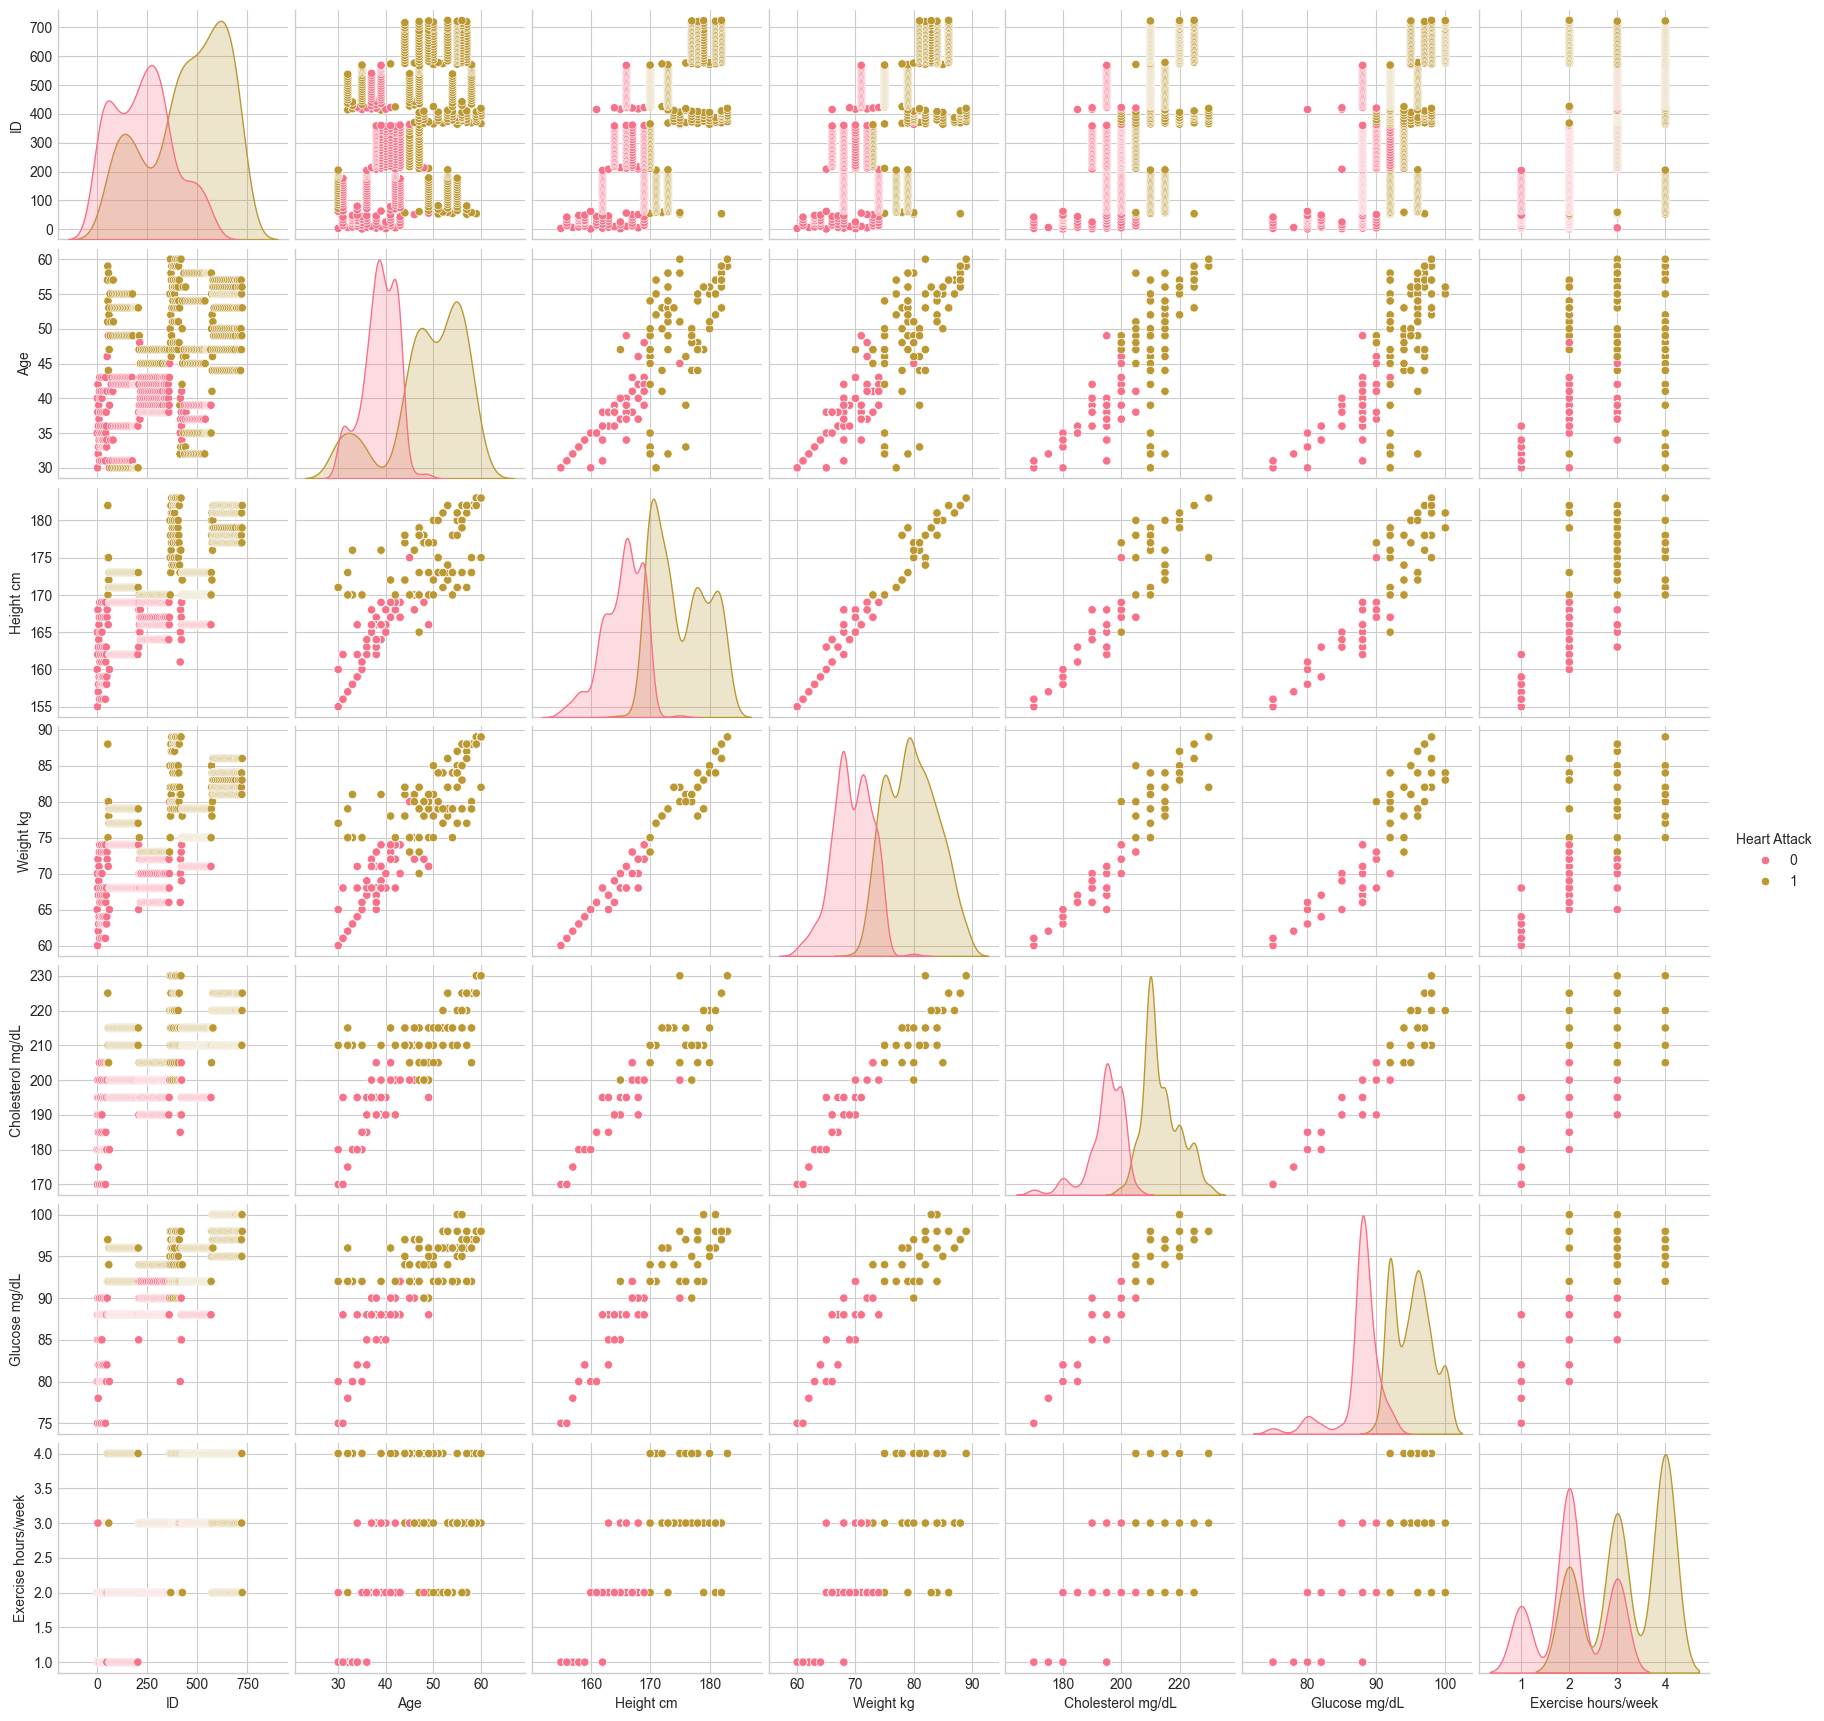

In [29]:
import seaborn as sns
sns.pairplot(df, hue='Heart Attack')